In [264]:
import pandas as pd 
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import datetime as dt 
import importlib
import helpers
import statsmodels.api as sm
importlib.reload(helpers)
from sklearn.decomposition import PCA


from helpers import data_extraction,montecarlosims, ConfigLoader,factor_models

import seaborn as sns
# get the data of my portfolio 




In [182]:
# read config file
config=ConfigLoader.configload()
config


{'stocks': ['PLTR',
  'AAPL',
  'MSFT',
  'NVDA',
  'BABA',
  'SOFI',
  'AVPT',
  'CRM',
  'GOOG',
  'DKNG',
  'LMT',
  'NOC',
  'NFLX',
  'PG',
  'UNH',
  'ADBE'],
 'weigths': [0.43,
  0.06,
  0.07,
  0.06,
  0.04,
  0.03,
  0.03,
  0.04,
  0.06,
  0.02,
  0.005,
  0.005,
  0.04,
  0.05,
  0.06,
  0.01]}

In [183]:
# get the data of my portfolio 
end=dt.datetime(year=2025,month=12,day=31)
start=dt.datetime(year=2021,month=1,day=1)
returns,meanReturns,Covmatrix=data_extraction.get_data(config['stocks'],start,end)


[*********************100%***********************]  16 of 16 completed


Monte Carlo Simulation:

1) Simulate random shocks 
2) Add the random shocks with Covariance matrix of the stocks 
3) Generate daily returns and cumulative returns over timeframe 

VAR:
- loss threshold for portfolio managers to note that there is a 5 % chance losses exceed VaR. If Losses does exceed VAR it also shows the Monte Carlo Simulation model has a problem 


CVAR (Conditional VaR):
- Average losses given that you are at the worst 5% of outcomes. This is useful for really grim outlooks/pessimism.




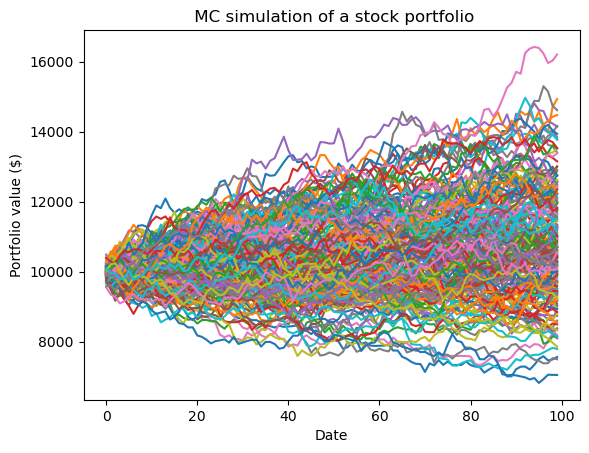

Expected return: 10835.892171566815
Median return: 10697.112363211543
Loss probability: 0.3
VaR (95%): 1686.76
CVaR (95%): 2156.20


In [184]:
# run monte carlo sims , var on my losses 
montecarlosims.monte_carlo(100,Covmatrix,200,meanReturns,config['weigths'],10000)


We wish to find out why the loss probability is so high at 28.5%?

We will try to delve in deeper into understanding how we can reduce our downside

1) Whether the loss probability is driven by systematic risk (interest rate etc)
2) How much unsystematic risk is my portfolio exposed?

Hypothesis: Alot of Tech stocks hence, very little diversification and hence, high unsystematic risk



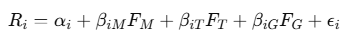

Running of Factor models:

We have decided to run factor models on individual stocks using factors:

- US 500 (market) -> This is market risk encapsulating economy wide shocks, interest rate changes and macro changes
- Tech factor (XLK) -> This is with regards to me being heavy on tech stocks. Hence, we are trying to segregate sector risk from market risk
- HML -> Value vs growth spread. This captures discount rate sensitivity and duration risk 
- SMB -> Size of company. Small cap premium or high business risk


Credits to https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/f-f_factors.html

for the Fama French daily data


1. Data Cleaning to ensure similar 

- time frames 
- returns

In [185]:
# read csv file in additional data 
ff_data = pd.read_csv("additional data/F-F_Research_Data_Factors_daily.CSV", skiprows=4)
ff_data.rename(columns={'Unnamed: 0':'Date'},inplace=True)
ff_data=ff_data.dropna(axis=0)
ff_data["Date"] = pd.to_datetime(ff_data["Date"], format="%Y%m%d")
ff_data=ff_data[ff_data['Date']>=start].reset_index()
ff_data.drop(0,axis=0,inplace=True)
ff_data.set_index(ff_data['Date'],inplace=True)
ff_data.drop(columns=['Date','index'],inplace=True)
ff_data=ff_data/100
ff_data

,Mkt-RF,SMB,HML,RF
Date,,,,
2021-01-05,0.0086,0.0122,0.0050,0.0000
2021-01-06,0.0079,0.0214,0.0394,0.0000
2021-01-07,0.0176,0.0032,-0.0081,0.0000
2021-01-08,0.0051,-0.0075,-0.0138,0.0000
2021-01-11,-0.0052,0.0026,0.0126,0.0000
...,...,...,...,...
2025-12-24,0.0029,0.0003,0.0001,0.0002
2025-12-26,-0.0006,-0.0032,0.0009,0.0002
2025-12-29,-0.0041,-0.0018,0.0007,0.0002


In [186]:
#get US 500 data and XLK - Tech 
marketdata = yf.download(
    ["SPY", "XLK"],
    start=start,
    end=end,
    auto_adjust=True
)
marketdata=marketdata[['Close']]

marketdata=marketdata.pct_change()
marketdata=marketdata.dropna()
marketdata=marketdata['Close']
marketdata



[*********************100%***********************]  2 of 2 completed


Ticker,SPY,XLK
Date,,
2021-01-05,0.006887,0.006489
2021-01-06,0.005979,-0.017245
2021-01-07,0.014857,0.026954
2021-01-08,0.005698,0.006465
2021-01-11,-0.006741,-0.008259
...,...,...
2025-12-23,0.004570,0.005442
2025-12-24,0.003518,0.002398
2025-12-26,-0.000101,0.001572


In [187]:
stockreturns=returns.dropna()
stockreturns

Ticker,AAPL,ADBE,AVPT,BABA,CRM,DKNG,GOOG,LMT,MSFT,NFLX,NOC,NVDA,PG,PLTR,SOFI,UNH
Date,,,,,,,,,,,,,,,,
2021-01-05,0.012364,0.000721,0.010782,0.055080,0.005492,0.060633,0.007337,0.012041,0.000964,-0.003940,0.006208,0.022210,0.006385,0.052632,-0.004098,-0.013448
2021-01-06,-0.033662,-0.039902,-0.037333,-0.053203,-0.024242,0.029739,-0.003234,-0.002179,-0.025929,-0.038998,0.008598,-0.058953,0.010526,-0.043089,-0.002469,0.041966
2021-01-07,0.034123,0.024512,0.019391,-0.003119,0.008466,0.015818,0.029943,-0.015746,0.028457,0.016784,-0.021929,0.057830,-0.009346,0.062022,0.579208,0.016032
2021-01-08,0.008631,0.015406,-0.006114,0.040943,0.018625,0.044806,0.011168,-0.018829,0.006093,0.002967,-0.014526,-0.005040,-0.000432,0.008000,-0.020899,-0.004493
2021-01-11,-0.023249,-0.022387,0.020506,-0.037343,-0.017069,0.030769,-0.022405,0.004701,-0.009699,-0.022140,0.022231,0.025966,-0.006773,0.028968,0.013340,-0.007265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,0.005130,-0.014292,-0.000734,0.001788,-0.004535,-0.010315,0.013972,-0.002109,0.003980,0.002896,-0.007868,0.030051,0.003434,0.000773,-0.005850,-0.001107
2025-12-24,0.005324,0.001589,-0.002203,-0.007737,0.006947,-0.002316,-0.000032,0.006631,0.002403,0.001497,0.003948,-0.003171,0.009149,0.000206,0.010666,0.008559
2025-12-26,-0.001497,0.002323,0.013245,0.014528,0.003091,0.012188,-0.002249,-0.005600,-0.000635,0.008864,-0.008552,0.010180,0.001730,-0.028120,-0.014920,0.012974


To find the True effect of Tech: 
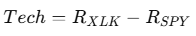

XLK to deduct the overall Market return as they will have significant overlap to reduce multicollinearity

In [188]:
marketdata['Tech']=marketdata['XLK']-marketdata['SPY']
marketdata

Ticker,SPY,XLK,Tech
Date,,,
2021-01-05,0.006887,0.006489,-0.000398
2021-01-06,0.005979,-0.017245,-0.023224
2021-01-07,0.014857,0.026954,0.012097
2021-01-08,0.005698,0.006465,0.000767
2021-01-11,-0.006741,-0.008259,-0.001518
...,...,...,...
2025-12-23,0.004570,0.005442,0.000872
2025-12-24,0.003518,0.002398,-0.001119
2025-12-26,-0.000101,0.001572,0.001673


In [189]:
# aligning all the data

data = stockreturns.join(ff_data, how="inner")
data=data.join(marketdata,how='inner')
data['SPY-RF']=data['SPY']-data['RF']
X=data[['RF','SPY-RF','Tech','HML','SMB']]
data

,AAPL,ADBE,AVPT,BABA,CRM,DKNG,GOOG,LMT,MSFT,NFLX,...,SOFI,UNH,Mkt-RF,SMB,HML,RF,SPY,XLK,Tech,SPY-RF
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-05,0.012364,0.000721,0.010782,0.055080,0.005492,0.060633,0.007337,0.012041,0.000964,-0.003940,...,-0.004098,-0.013448,0.0086,0.0122,0.0050,0.0000,0.006887,0.006489,-0.000398,0.006887
2021-01-06,-0.033662,-0.039902,-0.037333,-0.053203,-0.024242,0.029739,-0.003234,-0.002179,-0.025929,-0.038998,...,-0.002469,0.041966,0.0079,0.0214,0.0394,0.0000,0.005979,-0.017245,-0.023224,0.005979
2021-01-07,0.034123,0.024512,0.019391,-0.003119,0.008466,0.015818,0.029943,-0.015746,0.028457,0.016784,...,0.579208,0.016032,0.0176,0.0032,-0.0081,0.0000,0.014857,0.026954,0.012097,0.014857
2021-01-08,0.008631,0.015406,-0.006114,0.040943,0.018625,0.044806,0.011168,-0.018829,0.006093,0.002967,...,-0.020899,-0.004493,0.0051,-0.0075,-0.0138,0.0000,0.005698,0.006465,0.000767,0.005698
2021-01-11,-0.023249,-0.022387,0.020506,-0.037343,-0.017069,0.030769,-0.022405,0.004701,-0.009699,-0.022140,...,0.013340,-0.007265,-0.0052,0.0026,0.0126,0.0000,-0.006741,-0.008259,-0.001518,-0.006741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,0.005130,-0.014292,-0.000734,0.001788,-0.004535,-0.010315,0.013972,-0.002109,0.003980,0.002896,...,-0.005850,-0.001107,0.0032,-0.0094,-0.0020,0.0002,0.004570,0.005442,0.000872,0.004370
2025-12-24,0.005324,0.001589,-0.002203,-0.007737,0.006947,-0.002316,-0.000032,0.006631,0.002403,0.001497,...,0.010666,0.008559,0.0029,0.0003,0.0001,0.0002,0.003518,0.002398,-0.001119,0.003318
2025-12-26,-0.001497,0.002323,0.013245,0.014528,0.003091,0.012188,-0.002249,-0.005600,-0.000635,0.008864,...,-0.014920,0.012974,-0.0006,-0.0032,0.0009,0.0002,-0.000101,0.001572,0.001673,-0.000301


In [255]:
summaryoffactormodel,results,residuals=factor_models.preliminaryfactor_modelling(stockreturns,X)
summaryoffactormodel


===== AAPL =====
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     510.7
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          6.53e-261
Time:                        13:17:20   Log-Likelihood:                 3895.0
No. Observations:                1253   AIC:                            -7780.
Df Residuals:                    1248   BIC:                            -7754.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.809e-05      0.000  

,Alpha,Beta_Mkt,Beta_Tech,Beta_HML,Beta_SMB,R2,N
Ticker,,,,,,,
AAPL,0.000038,1.048312,0.528717,-0.096364,-0.109100,0.620783,1253
ADBE,-0.000602,1.010306,0.472685,-0.413423,-0.030338,0.457378,1253
AVPT,0.000200,0.910151,-0.002130,-0.543626,1.012448,0.289959,1253
BABA,-0.000058,0.837273,-0.166500,-0.441258,0.562360,0.142695,1253
CRM,-0.000132,1.030044,0.343090,-0.363345,0.221568,0.440902,1253
DKNG,0.000384,1.436771,-0.436507,-0.876546,1.429658,0.347300,1253
GOOG,0.000642,1.154963,-0.016615,-0.427549,-0.129906,0.514696,1253
LMT,0.000147,0.503494,-0.550638,0.109756,-0.200831,0.125059,1253
MSFT,0.000128,0.894473,0.668021,-0.241055,-0.272304,0.704370,1253


Total Portfolio Exposure 

In [192]:
portfolio_return = (stockreturns @ config['weigths']) #@ is a matrix multiplication 
y = portfolio_return - ff_data['RF']

In [254]:
portfolio_return=pd.DataFrame(y).dropna()
portfolio_return.rename(columns={0:'Portfolio'},inplace=True)
portfolio_exposure,full_results,portfolio_residuals=factor_models.preliminaryfactor_modelling(portfolio_return,X)
portfolio_exposure


===== Portfolio =====
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     1479.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:17:10   Log-Likelihood:                 4532.1
No. Observations:                1253   AIC:                            -9054.
Df Residuals:                    1248   BIC:                            -9028.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.

,Alpha,Beta_Mkt,Beta_Tech,Beta_HML,Beta_SMB,R2,N
Ticker,,,,,,,
Portfolio,0.000105,1.045988,0.24183,-0.30315,0.237819,0.825842,1253


What does this tell us about my portfolio exposure:

1) Firstly looking at adjusted R^2, systematic and sector risk can explain 82.5% of my portfolio - the rest being (unsystematic risk+unmodelled systematic risk)

2) Durbin watson == close to 2:
- No autocorrelation of residuals is involved

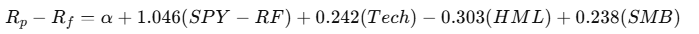
3) All factors have a significant effect in explaining the risk of my portfolio, with t stat for all 4 factors >1.96 at 5% significance level.

Individual factors:
- Positive Beta to market. If market goes up 1 percent, my portfolio goes up 1.04%. 
- Tech leaning due to a positive Beta for Beta_tech
- Negative HML: Portfolio moves when 'value' stock perception increases
- Positive SMB: Smaller cap stocks in portfolio contribute positively to portfolio return


# Use PCA to check if residuals are independant

In [261]:
factor_models.pca_residuals(residuals)

Explained variance ratios:
[0.22447831 0.14566339 0.12407011 0.10773343 0.07895417]
printing the components of pc1
SOFI    0.754515
PLTR    0.488558
DKNG    0.329543
AVPT    0.179198
BABA    0.139368
NFLX    0.138405
CRM     0.051526
NVDA    0.048243
ADBE    0.014039
GOOG    0.003128
MSFT   -0.014810
AAPL   -0.026412
LMT    -0.030840
NOC    -0.032635
UNH    -0.041950
PG     -0.053351
dtype: float64
printing the components of pc2
SOFI    0.642990
UNH     0.037039
PG      0.024179
GOOG    0.016975
AAPL    0.009075
MSFT    0.004550
LMT    -0.004561
NOC    -0.005428
ADBE   -0.013002
CRM    -0.028247
NVDA   -0.049299
AVPT   -0.064483
NFLX   -0.077172
BABA   -0.227659
DKNG   -0.415259
PLTR   -0.588546
dtype: float64


# With a higher value in PC1 and PC2 , this suggests that there is still some systematic risk that our current model is not able to capture.


PC1& PC2 having 36% in total suggests that perhaps 36% of the 17% of unexplained risk that we have identified might actually be systematic risk that we have failed to include in our model


Additionally, PC1 and PC 2 components have suggested that there is likely a speculative stock factor/high beta factor not modelled due to the strong presence of Sofi, Pltr and DKNG in the PC1 components

Sufficiency checks to see if model truly captured all the systematic risk of the portfolio:


Check correlation in residuals:

- If 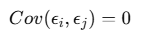 , there is no systematic risk 

- Else if 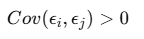 there is a presence of systematic risk 

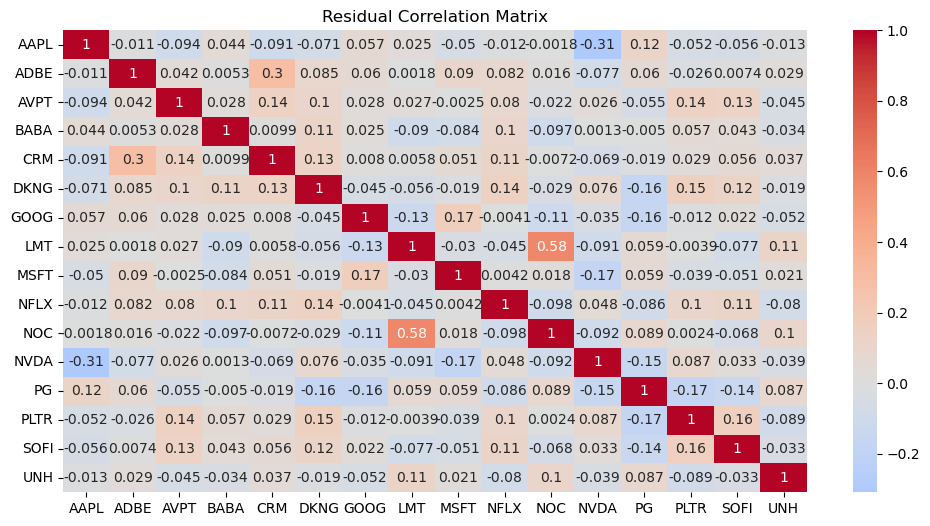

In [271]:
factor_models.visualise_residuals(residuals)

As visualised, there are some pairwise residual correlations >=0.15 (Mostly in tech and defence). Persistent residual correlation suggests that common systematic risk remains unaccounted for.

Defence cluster:
Most distinctly, would be NOC and LMT, defence stocks with residuals correlation up to 58%.
Magnitude is likely due to industry specific systmeatic exposure such as:
- Defence budget cycles
- Govt contract flow
- geopolitical risk

Hence, to capture defence specific performance relative to the broad market, we will add a Defence factor (XAR).


Speculative Growth/Risk on factor:
PCA on residuals revealed that the first PCs explains 36% of residual variance with higher loadings on :
- sofi
- pltr
- dkng
- avpt

These stocks tend to share characteristics of:
- Speculation
- High beta 
- Retail driven flows

To capture this aspect of speculative growth we introduce : ARKK (Speculative growth proxy) & MTUM (Momentum) 


In [267]:
tickers = ["XAR", "ARKK",'MTUM','SPY']   # or XAR
px = yf.download(tickers, start=start, end=end, auto_adjust=True)["Close"]
ret = px.pct_change().dropna()
#ret['Rate_impact']=ret['TLT']
ret['Defence_impact']= ret['XAR']-ret['SPY']
ret['Momentum_impact']=ret['MTUM']-ret['SPY']
ret['Speculation_impact']=ret['ARKK']-ret['SPY']
refine_X=X.copy()
all_factors=pd.concat([refine_X,ret[['Defence_impact','Momentum_impact','Speculation_impact']]],axis=1)
all_factors


[*********************100%***********************]  4 of 4 completed


,RF,SPY-RF,Tech,HML,SMB,Defence_impact,Momentum_impact,Speculation_impact
Date,,,,,,,,
2021-01-05,0.0000,0.006887,-0.000398,0.0050,0.0122,0.018633,0.002171,0.017734
2021-01-06,0.0000,0.005979,-0.023224,0.0394,0.0214,0.010139,-0.013718,-0.002300
2021-01-07,0.0000,0.014857,0.012097,-0.0081,0.0032,-0.017123,0.016090,0.064297
2021-01-08,0.0000,0.005698,0.000767,-0.0138,-0.0075,-0.009804,0.010824,0.023931
2021-01-11,0.0000,-0.006741,-0.001518,0.0126,0.0026,0.012793,-0.005524,-0.023158
...,...,...,...,...,...,...,...,...
2025-12-23,0.0002,0.004370,0.000872,-0.0020,-0.0094,-0.003249,-0.000900,-0.016596
2025-12-24,0.0002,0.003318,-0.001119,0.0001,0.0003,-0.001879,0.001004,-0.001779
2025-12-26,0.0002,-0.000301,0.001673,0.0009,-0.0032,-0.016343,-0.001621,-0.011678


In [268]:
summaryof_refinedfactormodel,results,residuals_ofrefinedmodel=factor_models.refinefactor_modelling(stockreturns,all_factors)
summaryof_refinedfactormodel


===== AAPL =====
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     329.3
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          5.17e-278
Time:                        13:41:15   Log-Likelihood:                 3944.0
No. Observations:                1253   AIC:                            -7872.
Df Residuals:                    1245   BIC:                            -7831.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const             

,Alpha,Beta_Mkt,Beta_Tech,Beta_HML,Beta_SMB,Beta_defence,Beta_vix,Beta_Momentum,R2,N
Ticker,,,,,,,,,,
AAPL,0.000046,1.028786,0.561741,-0.065887,-0.025638,-0.194057,None,-0.349054,0.649310,1253
ADBE,-0.000574,0.981129,0.476790,-0.354033,-0.028494,-0.131695,None,-0.109631,0.461942,1253
AVPT,0.000187,0.771507,0.095647,-0.285266,0.510263,0.179603,None,0.037768,0.310156,1253
BABA,0.000041,0.560800,-0.068031,0.103406,-0.133021,-0.151685,None,-0.044300,0.194458,1253
CRM,-0.000132,0.945954,0.405827,-0.207704,-0.018541,0.014655,None,-0.105272,0.450840,1253
DKNG,0.000495,0.991654,-0.259141,-0.005373,0.106071,0.070544,None,0.205622,0.447243,1253
GOOG,0.000638,1.125065,0.034493,-0.381033,-0.101198,-0.149036,None,-0.362689,0.535204,1253
LMT,-0.000107,0.575127,-0.368679,-0.094734,-0.431360,0.766581,None,-0.165776,0.344400,1253
MSFT,0.000097,0.913028,0.701818,-0.289968,-0.181661,-0.033085,None,-0.249375,0.717280,1253


In [270]:
# factor_models.visualise_residuals(residuals_ofrefinedmodel)

fullportfolio_exposure,full_results_portfolio_refined,portfolio_residuals_refine=factor_models.refinefactor_modelling(portfolio_return,all_factors)
fullportfolio_exposure
# 


===== Portfolio =====
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     1051.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:46:21   Log-Likelihood:                 4648.0
No. Observations:                1253   AIC:                            -9280.
Df Residuals:                    1245   BIC:                            -9239.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const        

,Alpha,Beta_Mkt,Beta_Tech,Beta_HML,Beta_SMB,Beta_defence,Beta_vix,Beta_Momentum,R2,N
Ticker,,,,,,,,,,
Portfolio,0.000118,0.945078,0.307726,-0.113512,-0.01509,-0.040149,None,-0.147546,0.855259,1253


All the additional variables that we have added specifically Momentum and Specualtion are significant at the 5% significance level. Defence factor is significant as well, however, due to the low weights of LMT and NOC, this factor is significant but only marginally significant relative to the other 2 newly added variables

# As seen in the table above, the model has a adjusted R^2 of 85.4% which is roughly a 3% increase in terms of explaining Systematic Risk.

Hence, the remaining 14.6% of unexplained risk will be:
- a small amount of unaccounted systematic risk
- unsystematic risk -> Related to specific stock news, characteristics etc 

In [272]:
factor_models.pca_residuals(residuals_ofrefinedmodel)

Explained variance ratios:
[0.18628553 0.14479578 0.12578809 0.11879423 0.08740453]
printing the components of pc1
SOFI    0.972773
PLTR    0.147085
AVPT    0.121974
NFLX    0.038037
GOOG    0.016735
CRM     0.012629
NVDA    0.008211
MSFT    0.001691
ADBE    0.000128
UNH    -0.000456
NOC    -0.014607
AAPL   -0.016376
LMT    -0.016479
PG     -0.017335
DKNG   -0.051452
BABA   -0.107440
dtype: float64
printing the components of pc2
PLTR    0.964089
AVPT    0.127464
DKNG    0.068917
NVDA    0.056129
NFLX    0.023730
MSFT    0.007182
NOC     0.001168
GOOG    0.000882
LMT    -0.001482
CRM    -0.003015
AAPL   -0.012566
ADBE   -0.014430
PG     -0.025751
UNH    -0.039478
BABA   -0.115194
SOFI   -0.172917
dtype: float64


The PCs are more evenly distributed now -> Less unaccounted Systematic risk 

Additionally, in PC1:
- Sofi dominates close to the entire loading 

in PC2:
- PLTR dominates close to the entire loading as well

These phenomenen suggests unsystematic risk where the residuals are not able to be modelled by a broad systematic risk factor


this also means given the total Unexplained Variance of the model now being = 14.6%

Sofi's unusystematic risk essentially accounts for = 14.6% x 18.6% x 97% = 2.63% of portfolio's total risk

Pltr's unusystematic risk essentially accounts for = 14.6% x 14.5% x 96.5% = 2.05% of portfolio's total risk